# Regresión Lineal Múltiple — fútbol con gráficas

Este notebook es **solo de regresión lineal múltiple**.

Ejemplo fácil:

> Queremos predecir los **goles** de un equipo usando varias estadísticas del partido.

Usaremos como variables predictoras:

```text
tiros_a_puerta
posesion
corners
ataques_peligrosos
```

Y como variable objetivo:

```text
goles
```

La idea es hacerlo parecido al de regresión simple, pero ahora usando varias X.

Veremos:

1. Crear datos.
2. Separar `X` e `y`.
3. Entrenar regresión lineal múltiple.
4. Ver fórmula del modelo.
5. Hacer predicciones.
6. Calcular residuos.
7. Dibujar valores reales vs predichos.
8. Dibujar gráfico de residuos.
9. Dibujar gráfica 3D con dos variables.
10. Dibujar plano de regresión.
11. Dibujar errores en 3D.
12. Dibujar superficie 3D del error.
13. Hacer una predicción nueva.
14. Explicación final para examen.

## 1. Importar librerías

Estas son las librerías necesarias.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Crear datos de fútbol

Cada fila representa el partido de un equipo.

Columnas:

- `equipo`: nombre del equipo.
- `tiros_a_puerta`: tiros entre los tres palos.
- `posesion`: porcentaje de posesión.
- `corners`: saques de esquina.
- `ataques_peligrosos`: ataques con peligro.
- `goles`: goles marcados.

Queremos predecir `goles`.

In [2]:
df = pd.DataFrame({
    "equipo": [
        "Real Madrid", "Barcelona", "Atletico", "Sevilla", "Betis",
        "Valencia", "Villarreal", "Real Sociedad", "Athletic", "Celta",
        "Getafe", "Osasuna", "Mallorca", "Girona", "Rayo",
        "Cadiz", "Alaves", "Granada", "Las Palmas", "Espanyol",
        "Leganes", "Eibar", "Levante", "Malaga", "Zaragoza",
        "Sporting", "Tenerife", "Oviedo", "Elche", "Huesca"
    ],
    "tiros_a_puerta": [
        9, 8, 6, 5, 5, 4, 6, 5, 4, 3,
        2, 3, 2, 7, 4, 2, 3, 2, 4, 3,
        3, 4, 5, 3, 4, 2, 5, 4, 3, 2
    ],
    "posesion": [
        62, 65, 54, 52, 50, 48, 55, 57, 49, 45,
        38, 43, 40, 59, 47, 36, 41, 39, 53, 44,
        42, 46, 51, 43, 48, 37, 50, 47, 44, 39
    ],
    "corners": [
        8, 7, 6, 5, 4, 5, 6, 5, 4, 3,
        2, 3, 2, 7, 4, 2, 3, 2, 5, 3,
        3, 4, 5, 3, 4, 2, 5, 4, 3, 2
    ],
    "ataques_peligrosos": [
        75, 78, 65, 58, 55, 52, 61, 60, 50, 45,
        35, 42, 38, 70, 48, 32, 40, 34, 54, 41,
        39, 47, 56, 40, 49, 33, 55, 46, 42, 36
    ],
    "goles": [
        4, 3, 2, 2, 1, 1, 2, 2, 1, 1,
        0, 1, 0, 3, 1, 0, 1, 0, 2, 1,
        1, 1, 2, 1, 1, 0, 2, 1, 1, 0
    ]
})

df

,equipo,tiros_a_puerta,posesion,corners,ataques_peligrosos,goles
0,Real Madrid,9,62,8,75,4
1,Barcelona,8,65,7,78,3
2,Atletico,6,54,6,65,2
3,Sevilla,5,52,5,58,2
4,Betis,5,50,4,55,1
5,Valencia,4,48,5,52,1
6,Villarreal,6,55,6,61,2
7,Real Sociedad,5,57,5,60,2
8,Athletic,4,49,4,50,1
9,Celta,3,45,3,45,1


## 3. Revisar los datos

Esto sirve para comprobar que el dataset está bien.

In [3]:
print("Filas y columnas:", df.shape)

print("\nColumnas:")
print(df.columns)

print("\nEstadísticas básicas:")
display(df.describe())

Filas y columnas: (30, 6)

Columnas:
Index(['equipo', 'tiros_a_puerta', 'posesion', 'corners', 'ataques_peligrosos',
       'goles'],
      dtype='object')

Estadísticas básicas:


,tiros_a_puerta,posesion,corners,ataques_peligrosos,goles
count,30.000000,30.000000,30.000000,30.0000,30.000000
mean,4.066667,47.466667,4.033333,49.2000,1.266667
std,1.799106,7.417283,1.650148,12.3523,0.980265
min,2.000000,36.000000,2.000000,32.0000,0.000000
25%,3.000000,42.250000,3.000000,40.0000,1.000000
50%,4.000000,47.000000,4.000000,47.5000,1.000000
75%,5.000000,51.750000,5.000000,55.7500,2.000000
max,9.000000,65.000000,8.000000,78.0000,4.000000


# 4. Separar X e y

En regresión lineal múltiple:

```text
X = varias variables predictoras
y = variable objetivo
```

Aquí:

```text
X = tiros_a_puerta, posesion, corners, ataques_peligrosos
y = goles
```

In [4]:
X = df[["tiros_a_puerta", "posesion", "corners", "ataques_peligrosos"]]
y = df["goles"]

print("Variables predictoras X:")
display(X.head())

print("Variable objetivo y:")
display(y.head())

Variables predictoras X:


,tiros_a_puerta,posesion,corners,ataques_peligrosos
0,9,62,8,75
1,8,65,7,78
2,6,54,6,65
3,5,52,5,58
4,5,50,4,55


Variable objetivo y:


0    4
1    3
2    2
3    2
4    1
Name: goles, dtype: int64

### Qué escribir en el examen

```text
He separado el dataset en X e y.

X contiene varias variables predictoras: tiros_a_puerta, posesion, corners y ataques_peligrosos.

y contiene la variable objetivo, que es goles.

Como X tiene varias columnas, se trata de una regresión lineal múltiple.
```

## 5. Nubes de puntos 2D

Antes de entrenar el modelo, miramos cómo se relaciona cada variable con los goles.

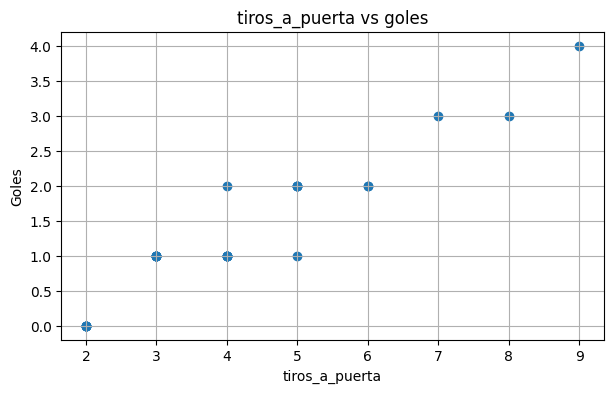

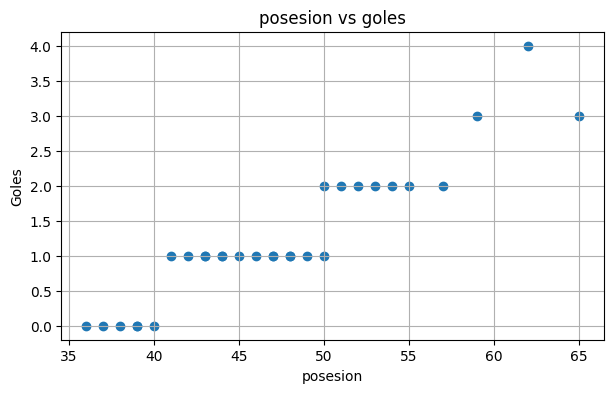

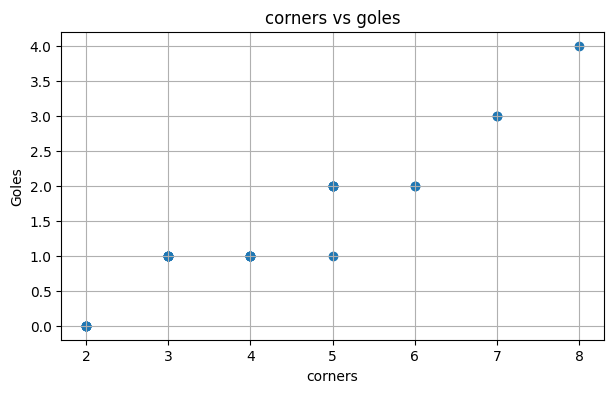

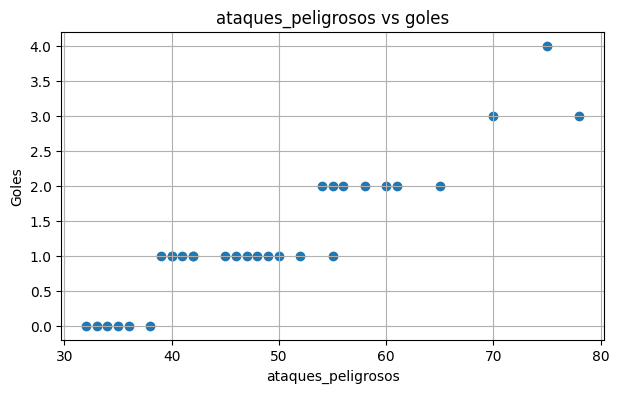

In [5]:
variables = ["tiros_a_puerta", "posesion", "corners", "ataques_peligrosos"]

for variable in variables:
    plt.figure(figsize=(7, 4))
    plt.scatter(df[variable], y)
    plt.xlabel(variable)
    plt.ylabel("Goles")
    plt.title(f"{variable} vs goles")
    plt.grid(True)
    plt.show()

### Qué escribir en el examen

```text
Represento gráficamente cada variable predictora frente a la variable objetivo para comprobar si existe relación.

Si los puntos suben hacia la derecha, la relación es positiva.

Si no se observa ningún patrón, esa variable puede aportar menos información al modelo.
```

## 6. Correlaciones

La correlación indica la relación entre cada variable y los goles.

Valores cercanos a 1 indican relación positiva fuerte.

In [6]:
correlaciones = df[["tiros_a_puerta", "posesion", "corners", "ataques_peligrosos", "goles"]].corr()

correlaciones

,tiros_a_puerta,posesion,corners,ataques_peligrosos,goles
tiros_a_puerta,1.000000,0.956270,0.974893,0.976927,0.947643
posesion,0.956270,1.000000,0.962204,0.986152,0.935551
corners,0.974893,0.962204,1.000000,0.975790,0.953601
ataques_peligrosos,0.976927,0.986152,0.975790,1.000000,0.935220
goles,0.947643,0.935551,0.953601,0.935220,1.000000


## 7. Entrenar modelo de regresión lineal múltiple

Creamos y entrenamos el modelo.

La fórmula general será:

```text
goles = b0 + b1·tiros_a_puerta + b2·posesion + b3·corners + b4·ataques_peligrosos
```

In [7]:
modelo = LinearRegression()

modelo.fit(X, y)

print("Intercepto b0:", modelo.intercept_)

coeficientes = pd.DataFrame({
    "variable": X.columns,
    "coeficiente": modelo.coef_
})

coeficientes

Intercepto b0: -2.1603842210455926


,variable,coeficiente
0,tiros_a_puerta,0.302842
1,posesion,0.083070
2,corners,0.360821
3,ataques_peligrosos,-0.065099


## 8. Fórmula del modelo

Con los coeficientes obtenidos podemos escribir la ecuación del modelo.

In [8]:
b0 = modelo.intercept_
coefs = modelo.coef_

print("Fórmula del modelo:")
print(
    f"goles = {b0:.3f} "
    f"+ ({coefs[0]:.3f})·tiros_a_puerta "
    f"+ ({coefs[1]:.3f})·posesion "
    f"+ ({coefs[2]:.3f})·corners "
    f"+ ({coefs[3]:.3f})·ataques_peligrosos"
)

Fórmula del modelo:
goles = -2.160 + (0.303)·tiros_a_puerta + (0.083)·posesion + (0.361)·corners + (-0.065)·ataques_peligrosos


### Qué escribir en el examen

```text
He entrenado un modelo LinearRegression con varias variables predictoras.

El modelo obtiene una ecuación de la forma:

y = b0 + b1·x1 + b2·x2 + b3·x3 + b4·x4

El intercepto b0 es el valor base de la predicción.

Cada coeficiente indica cuánto cambia la predicción de goles cuando aumenta esa variable, manteniendo constantes las demás.
```

## 9. Predicciones y residuos

Ahora hacemos predicciones.

El residuo o error es:

```text
residuo = valor real - valor predicho
```

In [9]:
y_pred = modelo.predict(X)

comparacion = df[["equipo", "tiros_a_puerta", "posesion", "corners", "ataques_peligrosos", "goles"]].copy()
comparacion["goles_predichos"] = y_pred
comparacion["residuo_error"] = y - y_pred

comparacion

,equipo,tiros_a_puerta,posesion,corners,ataques_peligrosos,goles,goles_predichos,residuo_error
0,Real Madrid,9,62,8,75,4,3.719669,0.280331
1,Barcelona,8,65,7,78,3,3.109918,-0.109918
2,Atletico,6,54,6,65,2,2.075932,-0.075932
3,Sevilla,5,52,5,58,2,1.701824,0.298176
4,Betis,5,50,4,55,1,1.370160,-0.370160
5,Valencia,4,48,5,52,1,1.457297,-0.457297
6,Villarreal,6,55,6,61,2,2.419400,-0.419400
7,Real Sociedad,5,57,5,60,2,1.986977,0.013023
8,Athletic,4,49,4,50,1,1.309745,-0.309745
9,Celta,3,45,3,45,1,0.639297,0.360703


## 10. Métricas del modelo

Calculamos:

- `R2`
- `MAE`
- `MSE`
- `RMSE`

In [10]:
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print("R2:", round(r2, 3))
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))

R2: 0.927
MAE: 0.23
MSE: 0.068
RMSE: 0.261


### Qué escribir en el examen

```text
R2 indica qué parte de la variación de los goles explica el modelo. Cuanto más cerca de 1, mejor.

MAE indica el error medio absoluto. Si MAE vale 0.3, el modelo se equivoca de media en 0.3 goles.

MSE es el error cuadrático medio y penaliza más los errores grandes.

RMSE es la raíz del MSE y se interpreta en goles.

Un buen modelo tiene R2 alto y MAE/RMSE bajos.
```

# 11. Gráfica: valores reales vs predichos

Esta gráfica compara los goles reales con los goles predichos.

Si el modelo fuera perfecto, todos los puntos estarían sobre la línea diagonal.

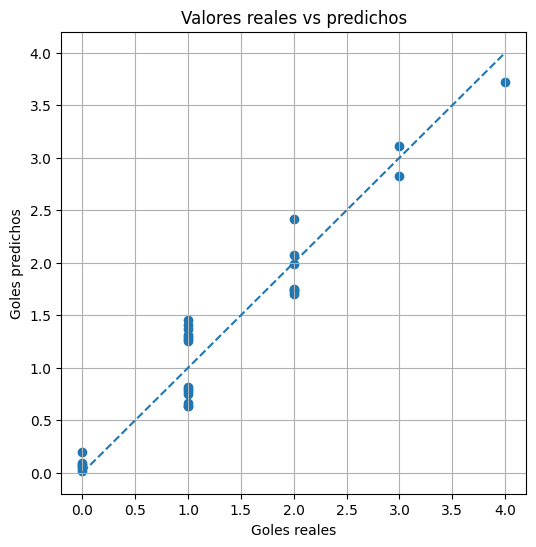

In [11]:
plt.figure(figsize=(6, 6))

plt.scatter(y, y_pred)

minimo = min(y.min(), y_pred.min())
maximo = max(y.max(), y_pred.max())

plt.plot([minimo, maximo], [minimo, maximo], linestyle="--")

plt.xlabel("Goles reales")
plt.ylabel("Goles predichos")
plt.title("Valores reales vs predichos")
plt.grid(True)
plt.show()

### Qué escribir en el examen

```text
La gráfica de valores reales frente a valores predichos permite comprobar visualmente si el modelo predice bien.

Cuanto más cerca estén los puntos de la diagonal, mejores serán las predicciones.
```

# 12. Gráfica de residuos

Esta gráfica muestra los errores del modelo.

- Eje X: goles predichos.
- Eje Y: residuos.

La línea horizontal en 0 significa error cero.

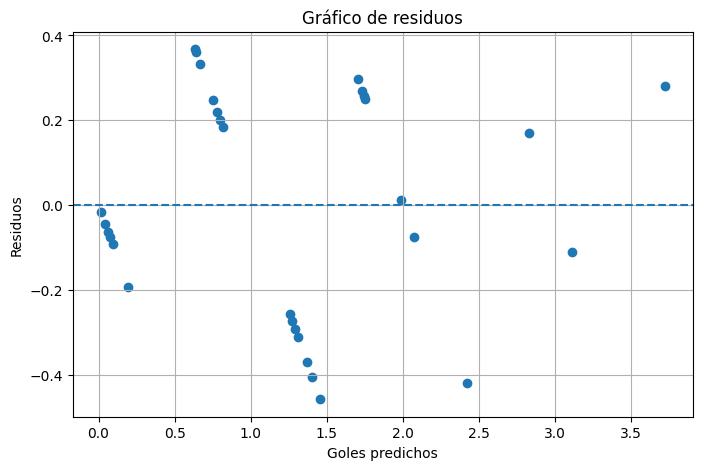

In [12]:
residuos = y - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuos)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Goles predichos")
plt.ylabel("Residuos")
plt.title("Gráfico de residuos")
plt.grid(True)
plt.show()

### Qué escribir en el examen

```text
El gráfico de residuos sirve para analizar los errores.

Lo ideal es que los residuos estén repartidos alrededor de cero.

Si aparece un patrón claro, puede indicar que el modelo lineal no se ajusta perfectamente.
```

# 13. Gráfica de errores con barras verticales

Aquí se ve la diferencia entre:

- goles reales;
- goles predichos.

Cada línea representa el error de un equipo.

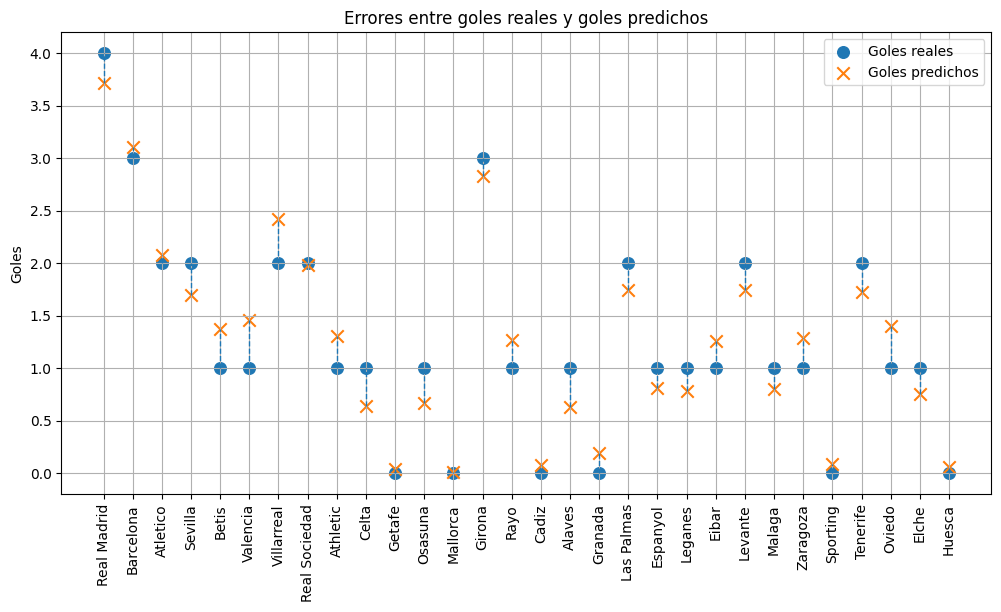

In [13]:
indices = np.arange(len(df))

plt.figure(figsize=(12, 6))

plt.scatter(indices, y, label="Goles reales", s=70)
plt.scatter(indices, y_pred, marker="x", s=80, label="Goles predichos")

for i in indices:
    plt.vlines(
        i,
        ymin=min(y.iloc[i], y_pred[i]),
        ymax=max(y.iloc[i], y_pred[i]),
        linestyle="--",
        linewidth=1
    )

plt.xticks(indices, df["equipo"], rotation=90)
plt.ylabel("Goles")
plt.title("Errores entre goles reales y goles predichos")
plt.legend()
plt.grid(True)
plt.show()

### Qué escribir en el examen

```text
Las líneas verticales representan los residuos.

Cuanto más corta sea la línea, menor es el error del modelo para ese dato.

Cuanto más larga sea la línea, mayor es la diferencia entre el valor real y el valor predicho.
```

# 14. Gráfica 3D de los datos

Como la regresión múltiple tiene muchas variables, no se pueden dibujar todas a la vez fácilmente.

Para hacer una gráfica 3D elegimos dos variables:

```text
X1 = tiros_a_puerta
X2 = ataques_peligrosos
Y = goles
```

Así podemos ver una nube de puntos en 3D.

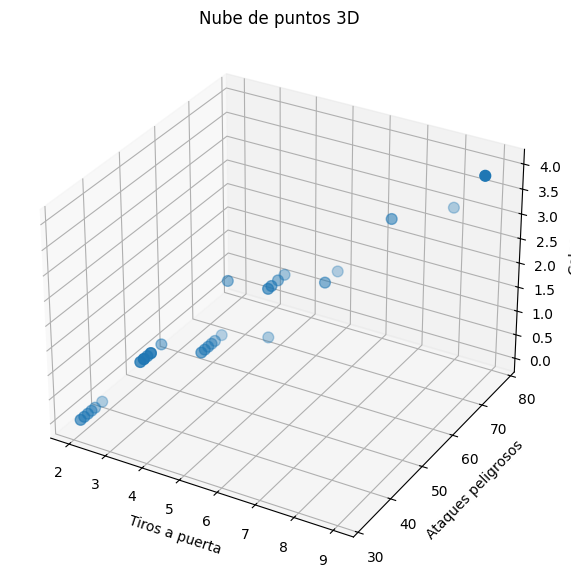

In [14]:
x1 = df["tiros_a_puerta"]
x2 = df["ataques_peligrosos"]
z = df["goles"]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x1, x2, z, s=60)

ax.set_xlabel("Tiros a puerta")
ax.set_ylabel("Ataques peligrosos")
ax.set_zlabel("Goles")
ax.set_title("Nube de puntos 3D")

plt.show()

# 15. Plano de regresión 3D con dos variables

Para poder dibujar un plano sencillo usamos solo dos variables:

```text
tiros_a_puerta
ataques_peligrosos
```

Esto sigue siendo regresión lineal múltiple porque usamos más de una variable.

La fórmula será:

```text
goles = b0 + b1·tiros_a_puerta + b2·ataques_peligrosos
```

In [15]:
X_2variables = df[["tiros_a_puerta", "ataques_peligrosos"]]
y = df["goles"]

modelo_2variables = LinearRegression()
modelo_2variables.fit(X_2variables, y)

y_pred_2variables = modelo_2variables.predict(X_2variables)

print("Intercepto:", modelo_2variables.intercept_)
print("Coeficientes:", modelo_2variables.coef_)

Intercepto: -1.1932182872586
Coeficientes: [0.40615675 0.01642644]


## 16. Dibujar el plano de regresión

El plano representa las predicciones del modelo usando dos variables.

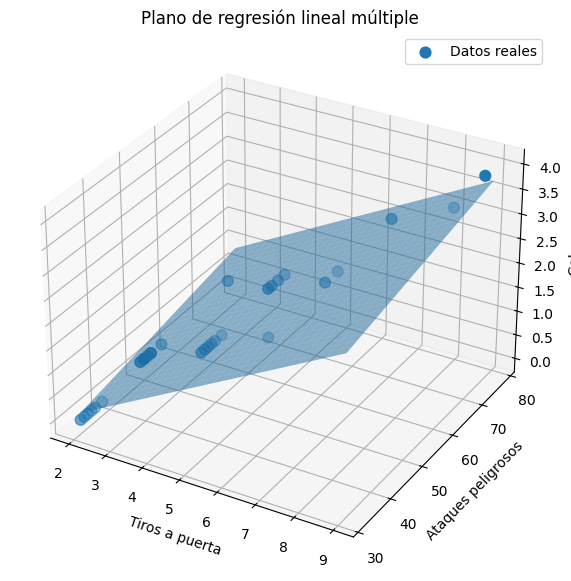

In [16]:
# Rango de valores para crear el plano
tiros_grid = np.linspace(df["tiros_a_puerta"].min(), df["tiros_a_puerta"].max(), 30)
ataques_grid = np.linspace(df["ataques_peligrosos"].min(), df["ataques_peligrosos"].max(), 30)

Tiros_grid, Ataques_grid = np.meshgrid(tiros_grid, ataques_grid)

# Predicciones para cada punto del plano
grid_df = pd.DataFrame({
    "tiros_a_puerta": Tiros_grid.ravel(),
    "ataques_peligrosos": Ataques_grid.ravel()
})

Goles_grid = modelo_2variables.predict(grid_df).reshape(Tiros_grid.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Puntos reales
ax.scatter(
    df["tiros_a_puerta"],
    df["ataques_peligrosos"],
    df["goles"],
    s=60,
    label="Datos reales"
)

# Plano de regresión
ax.plot_surface(Tiros_grid, Ataques_grid, Goles_grid, alpha=0.5)

ax.set_xlabel("Tiros a puerta")
ax.set_ylabel("Ataques peligrosos")
ax.set_zlabel("Goles")
ax.set_title("Plano de regresión lineal múltiple")

plt.legend()
plt.show()

### Qué escribir en el examen

```text
En la regresión lineal simple se dibuja una recta.

En la regresión lineal múltiple, si usamos dos variables predictoras, se puede representar un plano.

El plano intenta ajustarse lo mejor posible a los puntos reales.

La distancia entre cada punto real y el plano representa el error del modelo.
```

# 17. Plano 3D con errores verticales

Ahora dibujamos los errores desde cada punto real hasta el plano.

Cada línea vertical representa un residuo.

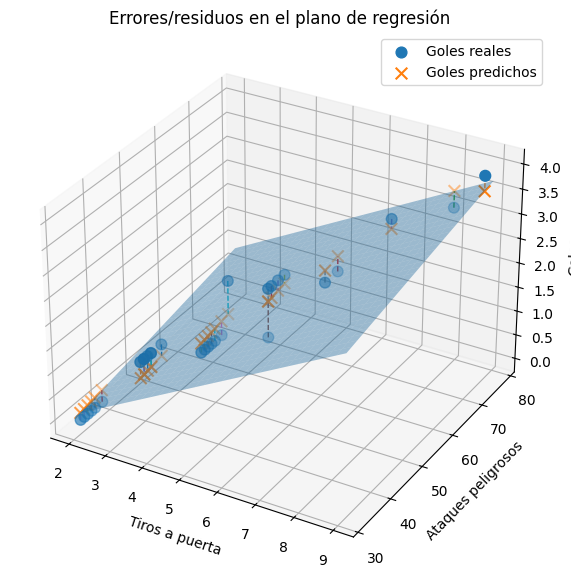

In [17]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Puntos reales
ax.scatter(
    df["tiros_a_puerta"],
    df["ataques_peligrosos"],
    df["goles"],
    s=60,
    label="Goles reales"
)

# Puntos predichos
ax.scatter(
    df["tiros_a_puerta"],
    df["ataques_peligrosos"],
    y_pred_2variables,
    marker="x",
    s=70,
    label="Goles predichos"
)

# Plano
ax.plot_surface(Tiros_grid, Ataques_grid, Goles_grid, alpha=0.4)

# Líneas de error
for i in range(len(df)):
    ax.plot(
        [df["tiros_a_puerta"].iloc[i], df["tiros_a_puerta"].iloc[i]],
        [df["ataques_peligrosos"].iloc[i], df["ataques_peligrosos"].iloc[i]],
        [df["goles"].iloc[i], y_pred_2variables[i]],
        linestyle="--",
        linewidth=1
    )

ax.set_xlabel("Tiros a puerta")
ax.set_ylabel("Ataques peligrosos")
ax.set_zlabel("Goles")
ax.set_title("Errores/residuos en el plano de regresión")

plt.legend()
plt.show()

### Qué escribir en el examen

```text
Las líneas verticales muestran el error entre el valor real y el valor predicho por el plano.

La regresión lineal múltiple busca el plano que minimiza esos errores.
```

# 18. Superficie 3D del error

Esta gráfica sirve para entender cómo se minimiza el error.

Para simplificar, usamos el modelo de dos variables:

```text
goles = b0 + b1·tiros_a_puerta + b2·ataques_peligrosos
```

Como no podemos dibujar todos los parámetros a la vez, dejamos fijo `b0` y variamos:

```text
b1 = coeficiente de tiros_a_puerta
b2 = coeficiente de ataques_peligrosos
```

El eje Z será el error MSE.

El punto más bajo representa los mejores coeficientes.

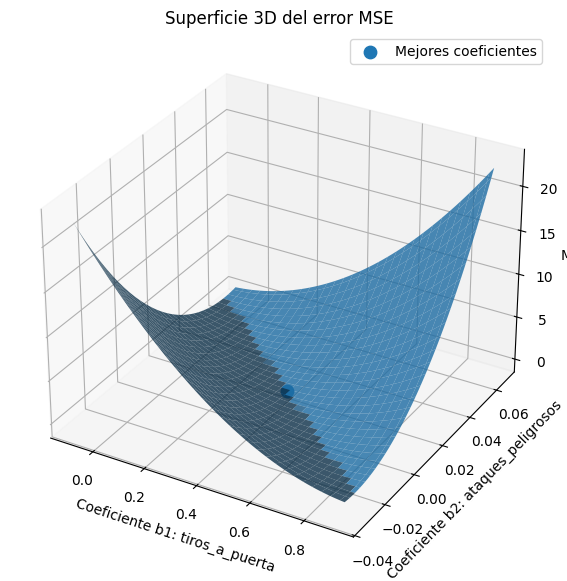

In [18]:
# Datos para el modelo de dos variables
x_tiros = df["tiros_a_puerta"].values
x_ataques = df["ataques_peligrosos"].values
y_real = df["goles"].values

b0_2 = modelo_2variables.intercept_
b1_2 = modelo_2variables.coef_[0]
b2_2 = modelo_2variables.coef_[1]

# Rangos de coeficientes
b1_valores = np.linspace(b1_2 - 0.5, b1_2 + 0.5, 60)
b2_valores = np.linspace(b2_2 - 0.05, b2_2 + 0.05, 60)

B1, B2 = np.meshgrid(b1_valores, b2_valores)

MSE_surface = np.zeros_like(B1)

for i in range(B1.shape[0]):
    for j in range(B1.shape[1]):
        pred = b0_2 + B1[i, j] * x_tiros + B2[i, j] * x_ataques
        MSE_surface[i, j] = np.mean((y_real - pred) ** 2)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(B1, B2, MSE_surface, alpha=0.8)

# Punto óptimo del modelo
mse_2variables = mean_squared_error(y_real, y_pred_2variables)

ax.scatter(b1_2, b2_2, mse_2variables, s=80, label="Mejores coeficientes")

ax.set_xlabel("Coeficiente b1: tiros_a_puerta")
ax.set_ylabel("Coeficiente b2: ataques_peligrosos")
ax.set_zlabel("MSE")
ax.set_title("Superficie 3D del error MSE")

plt.legend()
plt.show()

### Qué escribir en el examen

```text
La superficie 3D del error muestra cómo cambia el MSE según los coeficientes del modelo.

La regresión lineal busca los coeficientes que hacen mínimo el error.

El punto más bajo de la superficie representa el mejor modelo posible para esos datos.
```

# 19. Predicción nueva con el modelo completo

Ahora usamos el modelo con las cuatro variables.

Ejemplo:

Un equipo tiene:

- 7 tiros a puerta;
- 58% de posesión;
- 6 corners;
- 65 ataques peligrosos.

Queremos predecir sus goles.

In [19]:
nuevo_partido = pd.DataFrame({
    "tiros_a_puerta": [7],
    "posesion": [58],
    "corners": [6],
    "ataques_peligrosos": [65]
})

prediccion = modelo.predict(nuevo_partido)

print("Goles predichos:", prediccion[0])
print("Goles predichos redondeados:", round(prediccion[0]))

Goles predichos: 2.711055055419378
Goles predichos redondeados: 3


### Qué escribir en el examen

```text
Para hacer una predicción nueva, creo un DataFrame con las mismas columnas que X.

Después uso modelo.predict(nuevo_partido).

El resultado es la predicción de goles según las variables introducidas.
```

# Plantilla rápida de regresión lineal múltiple

Esta es la estructura que deberías recordar para el examen.

In [20]:
# 1. Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 2. Crear o cargar datos
# df = pd.read_csv("archivo.csv")

# 3. Separar X e y
# X = df[["variable1", "variable2", "variable3"]]
# y = df["variable_objetivo"]

# 4. Crear modelo
# modelo = LinearRegression()

# 5. Entrenar
# modelo.fit(X, y)

# 6. Predecir
# y_pred = modelo.predict(X)

# 7. Evaluar
# r2 = r2_score(y, y_pred)
# mae = mean_absolute_error(y, y_pred)
# mse = mean_squared_error(y, y_pred)
# rmse = np.sqrt(mse)

# 8. Resultados
# print("Intercepto:", modelo.intercept_)
# print("Coeficientes:", modelo.coef_)
# print("R2:", r2)
# print("MAE:", mae)
# print("MSE:", mse)
# print("RMSE:", rmse)

# 9. Gráfica valores reales vs predichos
# plt.scatter(y, y_pred)
# plt.plot([y.min(), y.max()], [y.min(), y.max()], linestyle="--")
# plt.xlabel("Valores reales")
# plt.ylabel("Valores predichos")
# plt.show()

# Explicación final para copiar en el examen

```text
En este ejercicio he aplicado una regresión lineal múltiple.

La variable objetivo y es goles.

Las variables predictoras X son tiros_a_puerta, posesion, corners y ataques_peligrosos.

Primero he separado el dataset en X e y.

Después he representado las variables para observar su relación con los goles.

A continuación he creado un modelo LinearRegression y lo he entrenado con fit(X, y).

El modelo obtiene una ecuación de la forma:

y = b0 + b1·x1 + b2·x2 + b3·x3 + b4·x4

El intercepto b0 es el valor base de la predicción.

Cada coeficiente indica cuánto cambia la predicción de goles cuando aumenta una variable, manteniendo las demás constantes.

Después he usado predict para obtener las predicciones.

He calculado los residuos como la diferencia entre los goles reales y los goles predichos.

También he evaluado el modelo con R2, MAE, MSE y RMSE.

R2 indica qué parte de la variación de los goles explica el modelo. Cuanto más cerca de 1, mejor.

MAE indica cuánto se equivoca el modelo de media.

RMSE indica el error típico del modelo en goles.

La gráfica de valores reales vs predichos sirve para comprobar si las predicciones están cerca de los valores reales.

La gráfica de residuos sirve para analizar los errores.

En la regresión lineal múltiple, cuando usamos dos variables predictoras, podemos representar el modelo como un plano en 3D.

Las líneas verticales entre los puntos y el plano representan los residuos.

La superficie 3D del error muestra que el modelo busca los coeficientes que minimizan el MSE.

En conclusión, la regresión lineal múltiple permite predecir los goles usando varias estadísticas del partido.
```

# Chuleta muy corta

```text
Regresión lineal múltiple = varias X para predecir una y.

X = tiros_a_puerta, posesion, corners, ataques_peligrosos
y = goles

Modelo:
goles = b0 + b1·x1 + b2·x2 + b3·x3 + b4·x4

fit() entrena.
predict() predice.

Residuo = valor real - valor predicho.

R2 alto = mejor.
MAE y RMSE bajos = mejor.

Con dos variables predictoras se puede dibujar un plano 3D.

La regresión busca minimizar el error MSE.
```